# YOLOv6 — final paper results

This notebook is the presentation layer for the final object-detection experiments. It inventories global concepts, computes layer-wise deletion AOC and insertion AUC directly from saved tensors, and links/displays the final figures. It does not train or rerun YOLO.

> Run all cells from top to bottom. Change only the configuration cell when moving the results directory or selecting a different final run.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Markdown, display

NOTEBOOK_DIR = Path.cwd() if (Path.cwd() / 'paper_results_utils.py').exists() else Path.cwd() / 'notebooks'
sys.path.insert(0, str(NOTEBOOK_DIR.resolve()))
from paper_results_utils import *
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_colwidth', 100)

## Configuration

In [2]:
REPO_ROOT = find_repo_root()
RESULTS_ROOT = resolve_results_root(REPO_ROOT)  # or set PAPER_RESULTS_DIR before starting Jupyter
DATASET = 'person_car'
MODEL = 'yolov6s6'
RUN = 'onlycar'
CLASS_TAG = 'c1'  # class 1 is car
OUTPUT_DIR = REPO_ROOT / 'paper output' / 'yolo'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Repository: {REPO_ROOT}')
print(f'Results:    {RESULTS_ROOT}')
print(f'Exports:    {OUTPUT_DIR}')

Repository: /home/heydari/paper/Segmentation-and-Object-detection-PCX
Results:    /home/heydari/paper/12-supp/code/results
Exports:    /home/heydari/paper/Segmentation-and-Object-detection-PCX/paper output/yolo


## Result completeness

In [3]:
model_root = RESULTS_ROOT / 'instance_perturbation' / DATASET / MODEL
display(Markdown(f'**Available perturbation runs:** {", ".join(sorted(p.name for p in model_root.iterdir() if p.is_dir())) if model_root.is_dir() else "none"}'))
artifact_table = artifact_inventory(RESULTS_ROOT)
concept_table = concept_inventory(RESULTS_ROOT, DATASET, MODEL)
display(artifact_table)
display(concept_table)
artifact_table.to_csv(OUTPUT_DIR / 'YOLO_artifact_inventory.csv', index=False)
concept_table.to_csv(OUTPUT_DIR / 'YOLO_concept_inventory.csv', index=False)

**Available perturbation runs:** logits, ones, onlycar, prob

,format,files,size_MB
0,.pth,4496,3117.648905
1,.pdf,2881,88.410522
2,.png,226,55.646190
3,.json,59,1.944530
4,.txt,19,0.038050
5,.log,10,42.609924
6,.md,8,0.017850
7,.ipynb,1,0.000230


,initialization,class,layer_files
0,logits,1,138
1,ones,0,138
2,ones,1,138
3,prob,0,138
4,prob,1,138


## Faithfulness results

Higher values indicate stronger effects for both reported reductions: deletion is sign-adjusted to AOC, while insertion is baseline-adjusted AUC. Error bars below are standard errors across samples.

In [4]:
summary_all = load_perturbation_summary(RESULTS_ROOT, DATASET, MODEL, RUN, CLASS_TAG)
display(perturbation_diagnostics(RESULTS_ROOT, DATASET, MODEL, RUN, summary_all))
summary = summary_all[summary_all['layer'].isin(YOLO_EVERY_EIGHTH_LAYERS)].copy()
print(f'Loaded {len(summary):,} method/layer/mode records from {summary.layer.nunique() if not summary.empty else 0} layers.')
display(score_table(summary))

/home/heydari/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,selected_directory,directory_exists,available_runs,candidate_pth_files,successfully_decoded_files,load_errors,first_load_error
0,/home/heydari/paper/12-supp/code/results/instance_perturbation/person_car/yolov6s6/onlycar,True,"logits, ones, onlycar, prob",274,274,0,


Loaded 252 method/layer/mode records from 18 layers.


,mode,method,mean_score,layers,samples
0,Deletion AOC,GradCAM,0.201611,18,100
1,Deletion AOC,Gradient,0.201603,18,100
2,Deletion AOC,LRP-epsilon,0.186598,18,100
3,Deletion AOC,LRP-gamma,0.165435,18,100
4,Deletion AOC,LRP-z+,0.156418,18,100
5,Deletion AOC,Activation,0.131533,18,100
6,Deletion AOC,Random,0.118317,18,100
7,Insertion AUC,Gradient,0.164225,18,100
8,Insertion AUC,GradCAM,0.163353,18,100
9,Insertion AUC,LRP-epsilon,0.149958,18,100


/home/heydari/paper/Segmentation-and-Object-detection-PCX/notebooks/paper_results_utils.py:399: RuntimeWarning: Mean of empty slice.
  means = np.asarray([values.mean() for values in per_layer])
/home/heydari/.local/lib/python3.10/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/heydari/.local/lib/python3.10/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/heydari/.local/lib/python3.10/site-packages/numpy/core/_methods.py:226: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/heydari/.local/lib/python3.10/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Saved exact every-eighth-layer plots to /home/heydari/paper/Segmentation-and-Object-detection-PCX/paper output


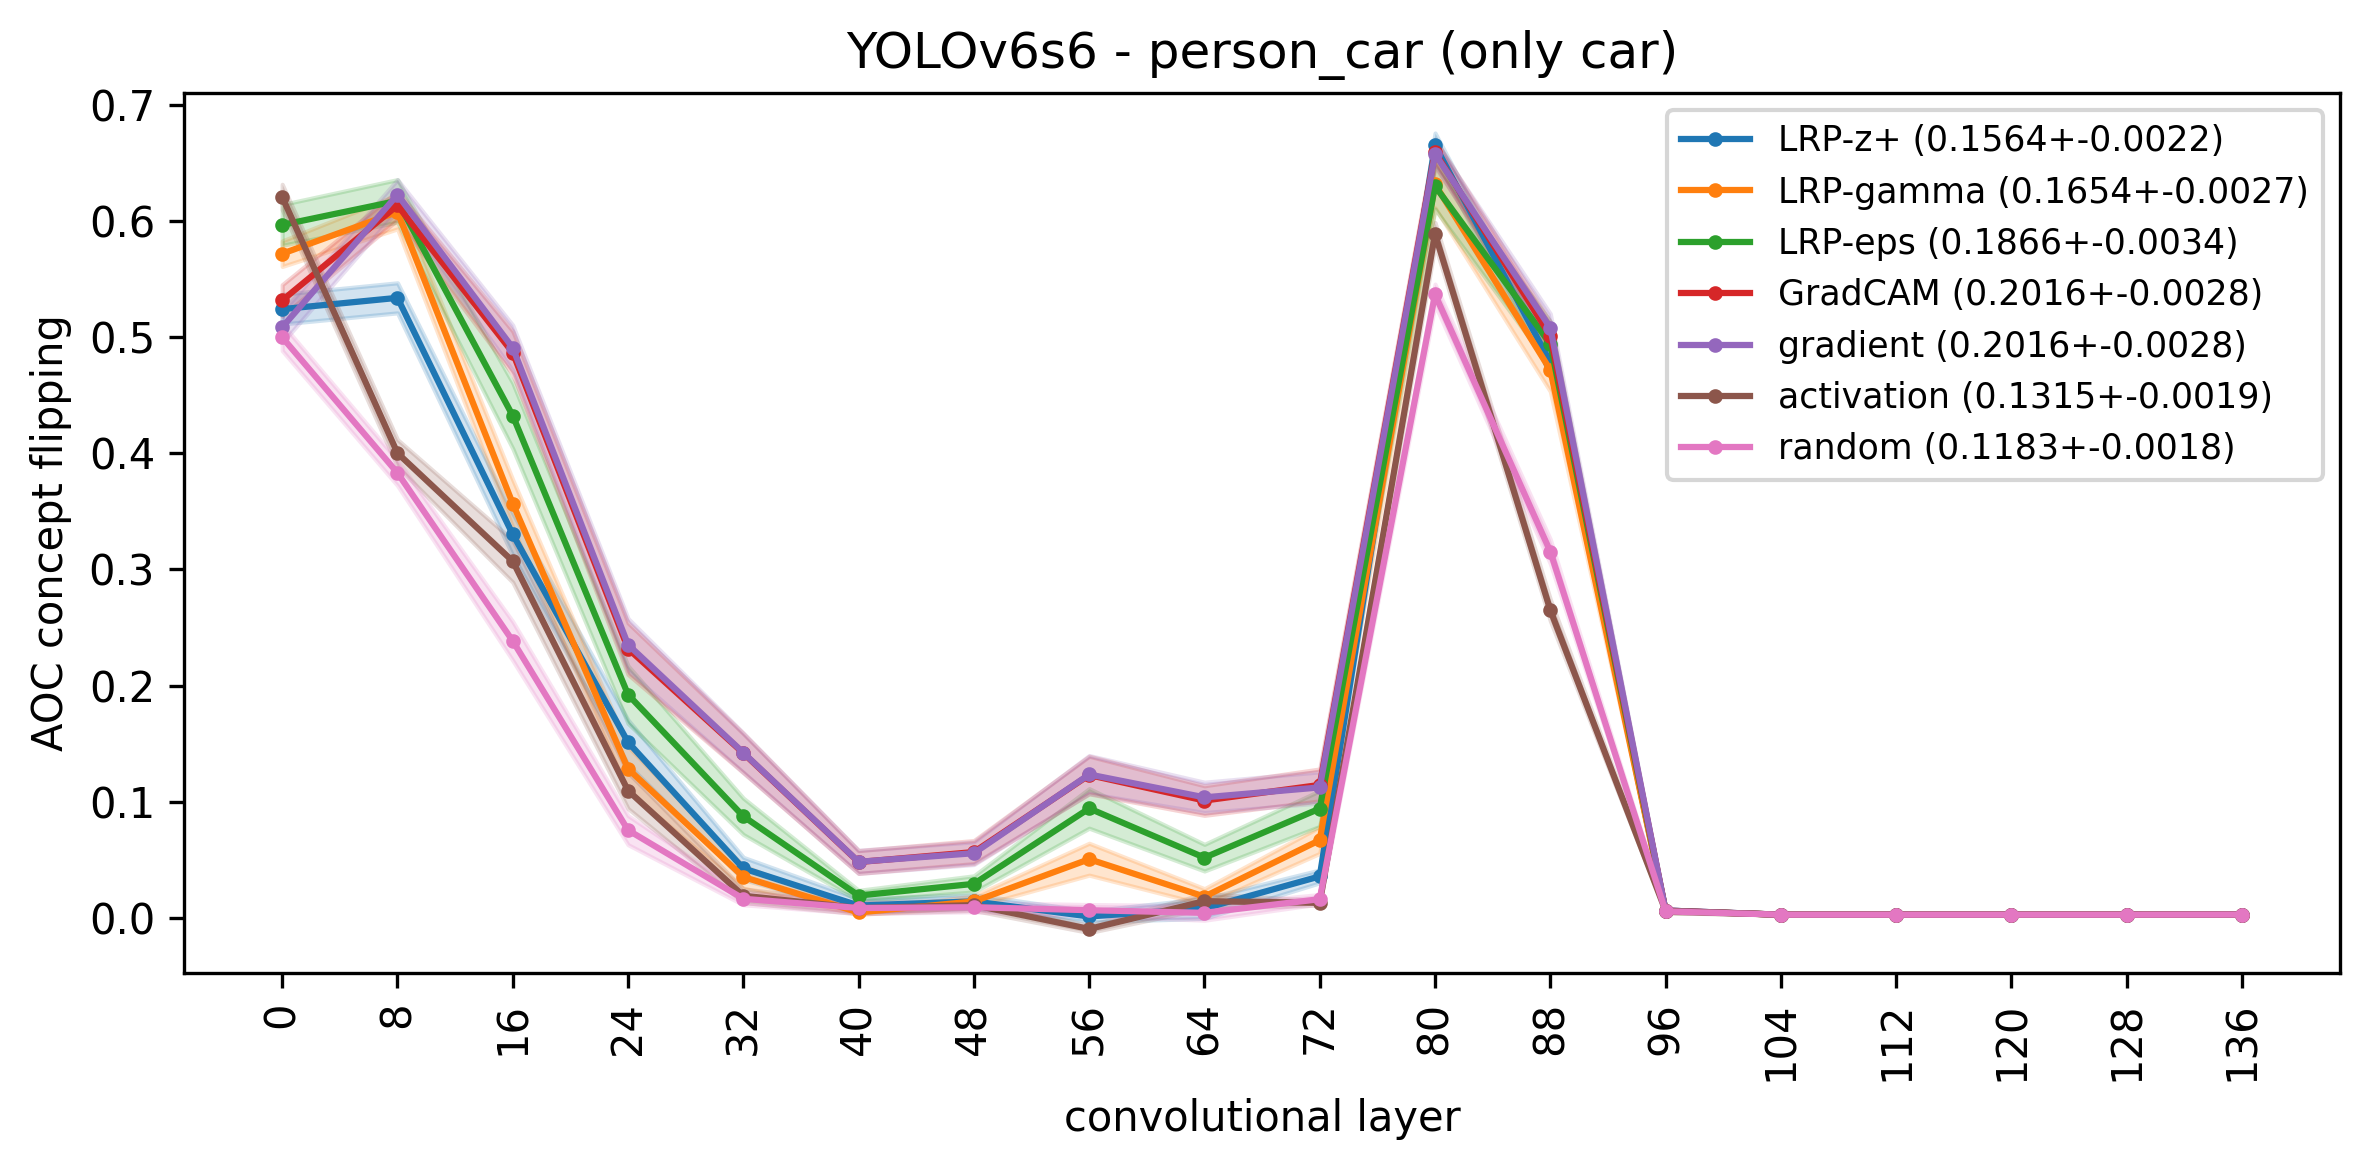

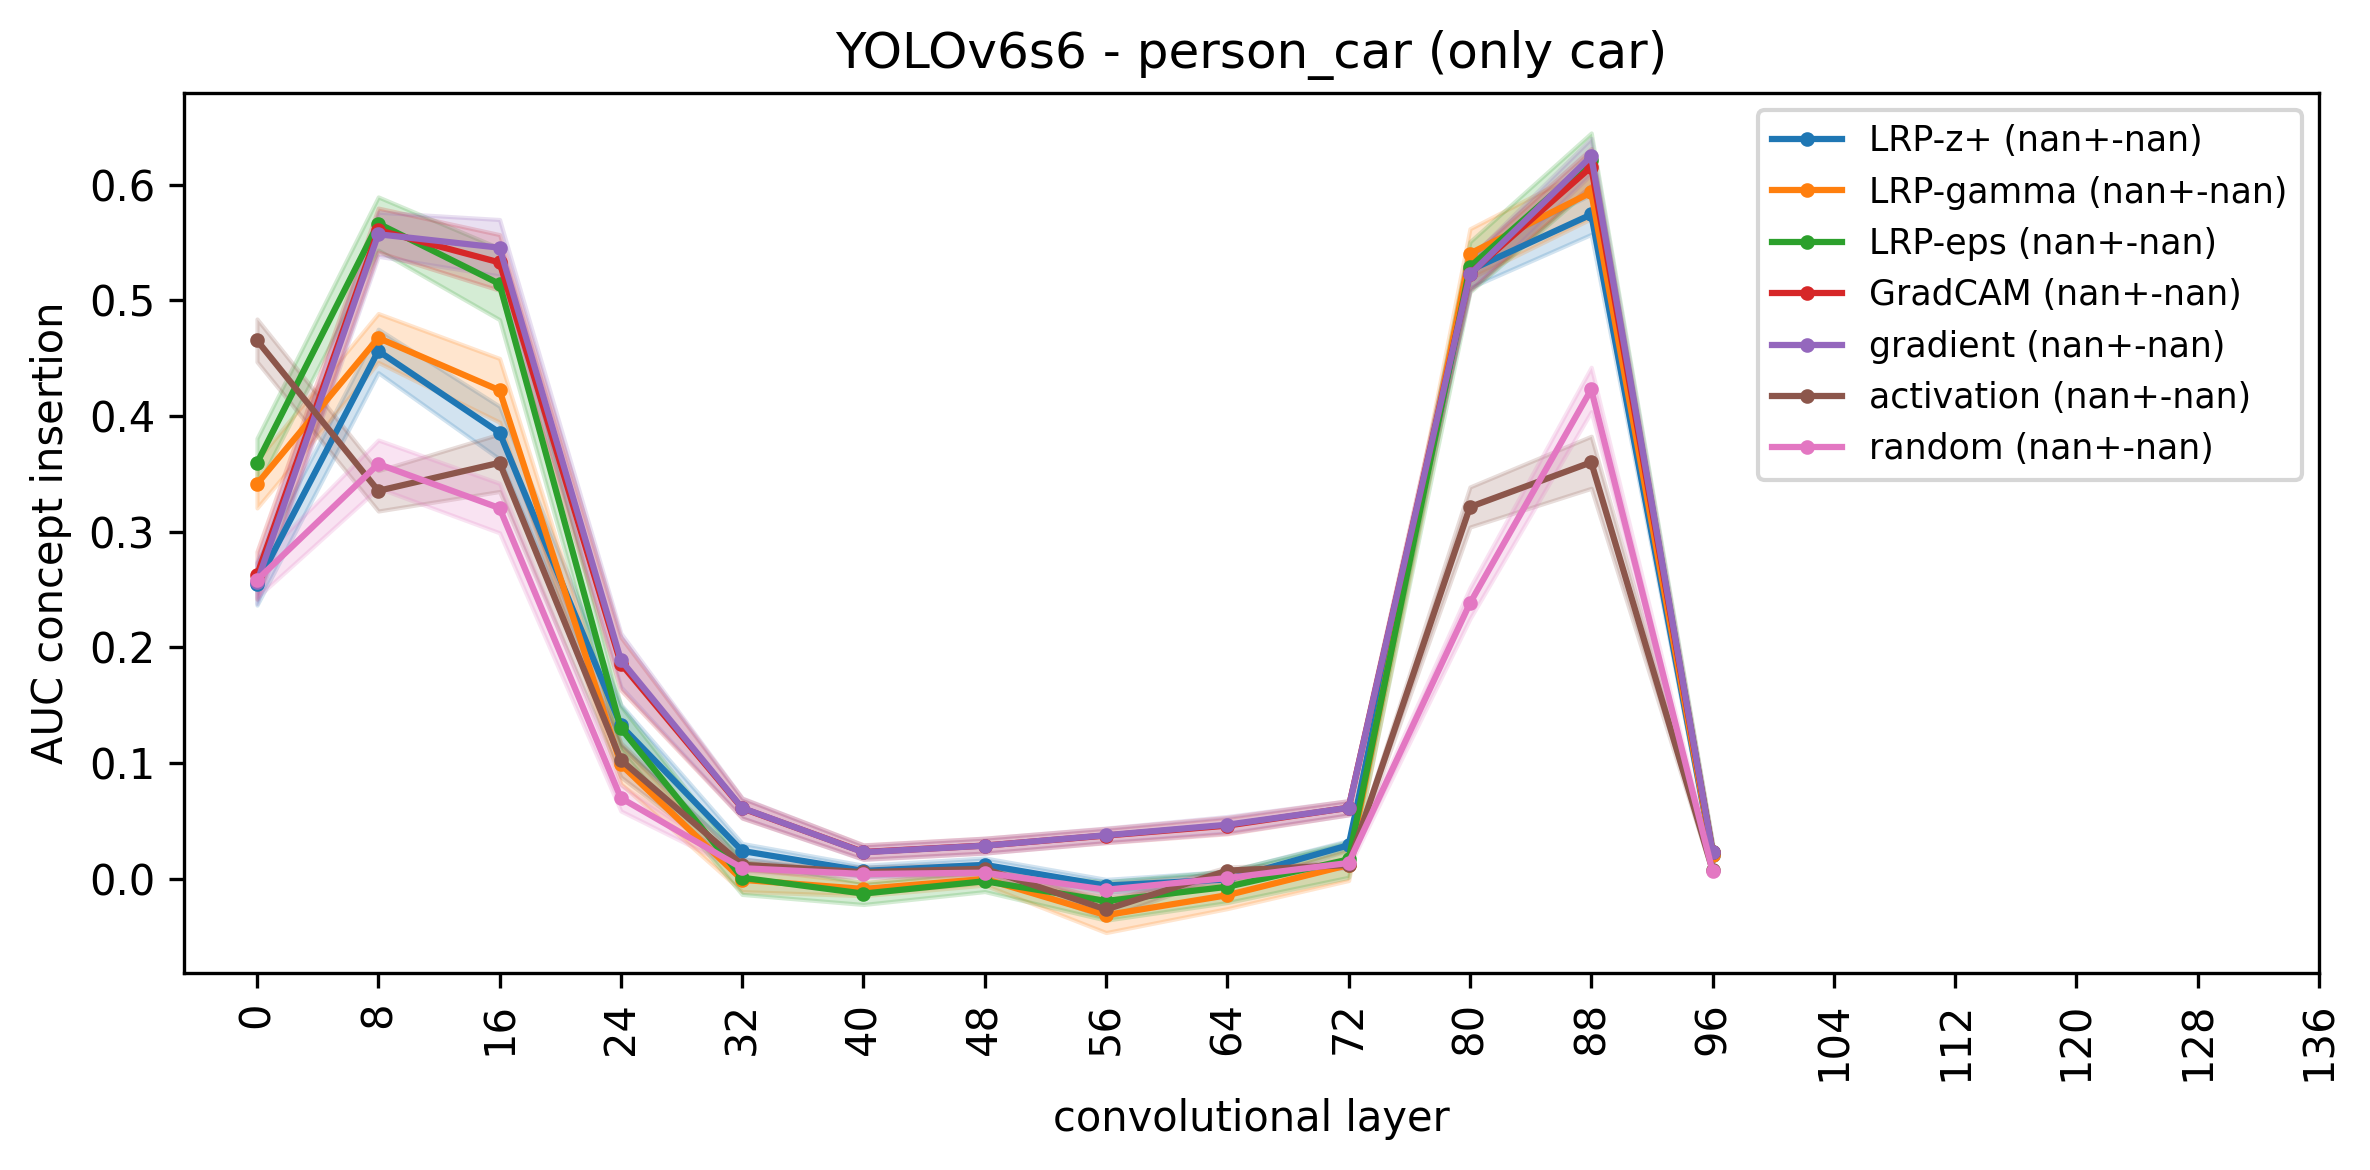

In [5]:
PAPER_OUTPUT_DIR = REPO_ROOT / 'paper output'
deletion_figure = plot_yolo_every_eighth(RESULTS_ROOT, RUN, CLASS_TAG, insertion=False)
insertion_figure = plot_yolo_every_eighth(RESULTS_ROOT, RUN, CLASS_TAG, insertion=True)
deletion_figure.savefig(PAPER_OUTPUT_DIR / 'concept_perturbation_yolov6s6_car_only_deletion.pdf', dpi=300, bbox_inches='tight', transparent=True)
insertion_figure.savefig(PAPER_OUTPUT_DIR / 'concept_perturbation_yolov6s6_car_only_insertion.pdf', dpi=300, bbox_inches='tight', transparent=True)
deletion_figure.savefig(OUTPUT_DIR / 'YOLO_every_eighth_deletion.png', dpi=300, bbox_inches='tight')
insertion_figure.savefig(OUTPUT_DIR / 'YOLO_every_eighth_insertion.png', dpi=300, bbox_inches='tight')
print(f'Saved exact every-eighth-layer plots to {PAPER_OUTPUT_DIR}')

## Paper-selected YOLO outputs

The final car-only deletion and insertion plots are embedded directly from `paper output`.

In [6]:
PAPER_OUTPUT_DIR = REPO_ROOT / 'paper output'
selected_yolo_plots = [
    PAPER_OUTPUT_DIR / 'concept_perturbation_yolov6s6_car_only_deletion.pdf',
    PAPER_OUTPUT_DIR / 'concept_perturbation_yolov6s6_car_only_insertion.pdf',
]
display_pdf_plots(selected_yolo_plots)

### Concept Perturbation Yolov6S6 Car Only Deletion

### Concept Perturbation Yolov6S6 Car Only Insertion

## Final rendered figures

In [7]:
figures = [
    PAPER_OUTPUT_DIR / 'concept_perturbation_yolov6s6_car_only_deletion.pdf',
    PAPER_OUTPUT_DIR / 'concept_perturbation_yolov6s6_car_only_insertion.pdf',
]
figures = [path for path in figures if path.is_file()]
print(f'{len(figures)} every-eighth-layer YOLO figures.')
display_gallery(figures)
figure_manifest = export_figure_artifacts(figures, OUTPUT_DIR)
display(figure_manifest)

2 every-eighth-layer YOLO figures.


**concept_perturbation_yolov6s6_car_only_deletion.pdf**  
`/home/heydari/paper/Segmentation-and-Object-detection-PCX/paper output/concept_perturbation_yolov6s6_car_only_deletion.pdf`

[Open PDF](file:///home/heydari/paper/Segmentation-and-Object-detection-PCX/paper%20output/concept_perturbation_yolov6s6_car_only_deletion.pdf)

**concept_perturbation_yolov6s6_car_only_insertion.pdf**  
`/home/heydari/paper/Segmentation-and-Object-detection-PCX/paper output/concept_perturbation_yolov6s6_car_only_insertion.pdf`

[Open PDF](file:///home/heydari/paper/Segmentation-and-Object-detection-PCX/paper%20output/concept_perturbation_yolov6s6_car_only_insertion.pdf)

,source,exported_to
0,/home/heydari/paper/Segmentation-and-Object-detection-PCX/paper output/concept_perturbation_yolo...,/home/heydari/paper/Segmentation-and-Object-detection-PCX/paper output/yolo/source_figures/001_c...
1,/home/heydari/paper/Segmentation-and-Object-detection-PCX/paper output/concept_perturbation_yolo...,/home/heydari/paper/Segmentation-and-Object-detection-PCX/paper output/yolo/source_figures/002_c...


## Export the summary table

The CSV is written automatically to the configured output directory.

In [8]:
final_table = score_table(summary)
display(final_table)
final_table.to_csv(OUTPUT_DIR / 'YOLO_final_results.csv', index=False)
summary.to_csv(OUTPUT_DIR / 'YOLO_layer_results.csv', index=False)
print(f'Complete YOLO result bundle: {OUTPUT_DIR}')

,mode,method,mean_score,layers,samples
0,Deletion AOC,GradCAM,0.201611,18,100
1,Deletion AOC,Gradient,0.201603,18,100
2,Deletion AOC,LRP-epsilon,0.186598,18,100
3,Deletion AOC,LRP-gamma,0.165435,18,100
4,Deletion AOC,LRP-z+,0.156418,18,100
5,Deletion AOC,Activation,0.131533,18,100
6,Deletion AOC,Random,0.118317,18,100
7,Insertion AUC,Gradient,0.164225,18,100
8,Insertion AUC,GradCAM,0.163353,18,100
9,Insertion AUC,LRP-epsilon,0.149958,18,100


Complete YOLO result bundle: /home/heydari/paper/Segmentation-and-Object-detection-PCX/paper output/yolo
